In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
#from sklearn.dummy import DummyClassifier
#train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
#X_tr = train.drop("label", axis=1)
#y_tr = train['label']

#dummy = DummyClassifier(strategy="most_frequent").fit(X_tr,y_tr)
#X_test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
#y_pred = dummy.predict(X_test)
#submission = pd.DataFrame({"ID":range(1,102001),"label":y_pred})
#submission.to_csv('submission.csv', index=False)

## Phase 1: Data Loading & Exploratory Data Analysis (EDA)

The first step in any Machine Learning project is to understand the data we are working with. We call this Exploratory Data Analysis (EDA). So I have loaded our data and draw some pictures (graphs/charts) to understand it better.


### 1. Understanding the Data

### Step 1: Importing Libraries and Loading Data
First, we need to import all our tools (libraries). 
- `pandas` and `numpy` are for handling data (like Excel spreadsheets).
- `matplotlib` and `seaborn` are for drawing graphs and charts.
- `wordcloud` is to make nice text visualizations.

Then I have loaded our Train and Test data.

In [3]:
# Import data handling and visualization libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [4]:
# To ingnore all the warning messages.
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Load the datasets:-
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

# Print the shape to see how many rows and columns we have 
print(f"Training data shape: {train.shape}")
print(f"Testing data shape: {test.shape}")


Training data shape: (198000, 15)
Testing data shape: (102000, 14)


Training data has 198,000 rows and 15 columns. Testing data has 102,000
rows and 14 columns. Because the "label" column is
missing — that is what we need to predict!

In [6]:
# Look at the first 5 rows of training data
train.head(5)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [7]:
# Look at the first 5 rows of test data
test.sample(5)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
78959,2023-06-22 01:50:19.867093+00:00,40,0,0,0,0,0,0,4,NaN,NaN,NaN,False,We should do a reverse-Mariel Boat Lift. After...
98103,2024-06-09 09:24:14.022083+00:00,73,0,0,0,1,0,6,6,none,none,female,False,"She is an attorney, but very inept at being one"
38730,2023-08-21 20:24:52.788664+00:00,72,6,0,0,9,4,0,4,NaN,NaN,NaN,False,Here is a thought....Maybe you should have org...
100835,2024-05-03 19:23:45.439161+00:00,84,0,0,0,1,0,4,6,none,none,none,False,"Since the 6th grade, I've been listening and s..."
29124,2023-11-06 05:17:02.515267+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"so, some clown wasted all day babbling about s..."


In [8]:
# Look at the first 5 rows of sample data
sample.sample(5)

,ID,label
59001,59002,0
9313,9314,0
56388,56389,0
11478,11479,0
15563,15564,0


In [9]:
# Look at the some information about the training data
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [10]:
# Look at the some information about the test data
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


In [11]:
# Look at the some statstical discription about the training data
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [12]:
# Look at the some statstical discription about the test data
test.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2
count,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000,102000.000000
mean,68.359422,0.280078,0.048353,0.118902,2.609402,0.661667,1.903078,7.956206
std,27.923491,1.043353,0.257278,0.480484,4.966033,1.965536,26.273483,15.186746
min,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000
max,129.000000,95.000000,8.000000,19.000000,189.000000,95.000000,1866.000000,1798.000000


### 2. Understanding the Target Variable (Labels)

### Step 2: Distribution of the Target Variable (`label`)
Our goal is to predict the `label` column. Before we start, we need to understand: how
many comments belong to each label? Is the data balanced or is one label way more
common than others?

In [13]:
# Set the style for our graphs to look nice!
sns.set_theme(style="whitegrid")


In [14]:
# Print the exact numbers
print("Exact counts for each label:")
print(train['label'].value_counts())

Exact counts for each label:
label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64


**The Result**: Label 0 has a MASSIVE rows in dataset ~(114,000). Label 2 has a medium rows
~(62,000). Label 1 has a smaller rows ~(16,000). Label 3 has rows ~(5,500). This
immediately tells us our data is very imbalanced!

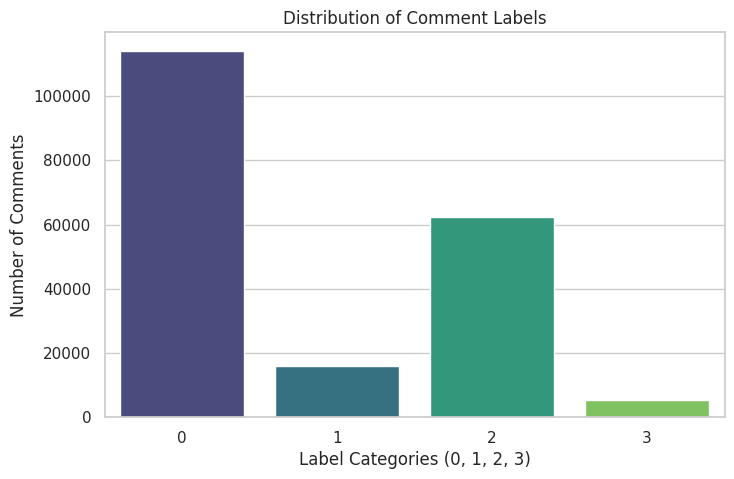

In [15]:
# Create a bar chart showing the count of each label
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=train, palette='viridis')
plt.title('Distribution of Comment Labels')
plt.xlabel('Label Categories (0, 1, 2, 3)')
plt.ylabel('Number of Comments')
plt.show()

**What the charts tell us:** Looking at our bar chart, we can see exactly how unbalanced our data is! Label `0` is massive (114,173 comments, meaning nearly 60% of our dataset is just this one category). Label `3` is incredibly rare (only 5,469 comments). In Data Science, this is called an **Imbalanced Dataset**. If we aren't careful, our model might just guess '0' every time to look smart! To fix this, I will use a special setting later called `class_weight` to force the model to pay extra attention to those rare labels like `3`.

### 3. Visualizing Missing Data

### Step 3: Checking for Missing Data (Null Values)
Missing data can break our models. Let's see which columns have missing values.

In [16]:
# Calculate the percentage of missing values in each column
missing_percentage = (train.isnull().sum() / len(train)) *100
missing_percentage

created_date     0.000000
post_id          0.000000
emoticon_1       0.000000
emoticon_2       0.000000
emoticon_3       0.000000
upvote           0.000000
downvote         0.000000
if_1             0.000000
if_2             0.000000
race            73.445960
religion        73.445960
gender          73.445960
disability       0.000000
comment          0.000505
label            0.000000
dtype: float64

In [17]:
# Filter only columns that have missing values
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)


In [18]:
print("Percentage of missing values:")
print(missing_percentage)

Percentage of missing values:
race        73.445960
religion    73.445960
gender      73.445960
comment      0.000505
dtype: float64


**The Result**: 3 columns (race, religion, gender all at ~73.4% missing!) and 1 tiny
almost-invisible rows (comment at 0.0005%). This picture immediately screams: "3
columns are in serious trouble!"

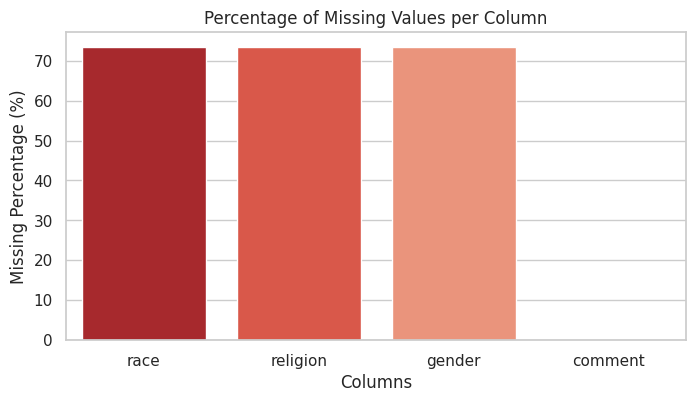

In [19]:
# Plot a bar chart of missing values
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_percentage.index, y=missing_percentage.values, palette='Reds_r')
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Columns')
plt.show()


**What the missing data chart shows us:** The bright colored bars tell us a very clear story! Exactly 73.4% of users completely skipped filling out their `race`, `religion`, and `gender`. Because nearly 3/4ths of this data is a completely blank void, we absolutely cannot rely on standard methods to handle them. I will have to use a very clever custom Binary Encoding trick to safely compress this without breaking our model. (We also discovered exactly 1 missing comment text, which we will just fill with a blank space safely).


### 4. Text Analysis: Making a WordCloud

### Step 4: WordCloud of the Comments
Let's see the most frequently used words in our comments visually. Words that appear bigger in the picture are used more frequently.

In [20]:
# Fill the few missing comment with an empty string so WordCloud doesn't crash
text_data = train['comment'].fillna('').values

In [21]:
# Combine all comments into one giant piece of text with spaces between each.
all_text = " ".join(text_data)

In [22]:
# Generate the WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_text)

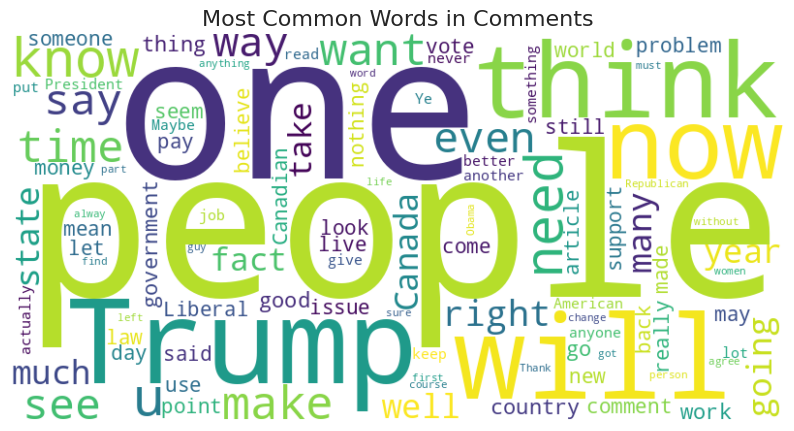

In [23]:
# Display the generated image
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Comments', fontsize=16)
plt.show()

**What the WordCloud reveals:** This picture is a literal map of the most common topics people are talking about! Huge words like **"people"**, **"Trump"**, **"think"**, **"time"**, and **"say"** immediately stand out. This tells us the comments are highly political, opinionated, and social. Because specific words are so crucial here, building a massive text-understanding matrix (TF-IDF) in our model is going to be our most powerful weapon!

### 5. Outlier Detection

### Step 5: Outlier Detection
Outliers are extreme numbers that can confuse our model. For instance, in `upvote` most values are low but a few might be hundreds. Let's look at `upvote`, `downvote`, `if_1`, and `if_2` using Boxplots.

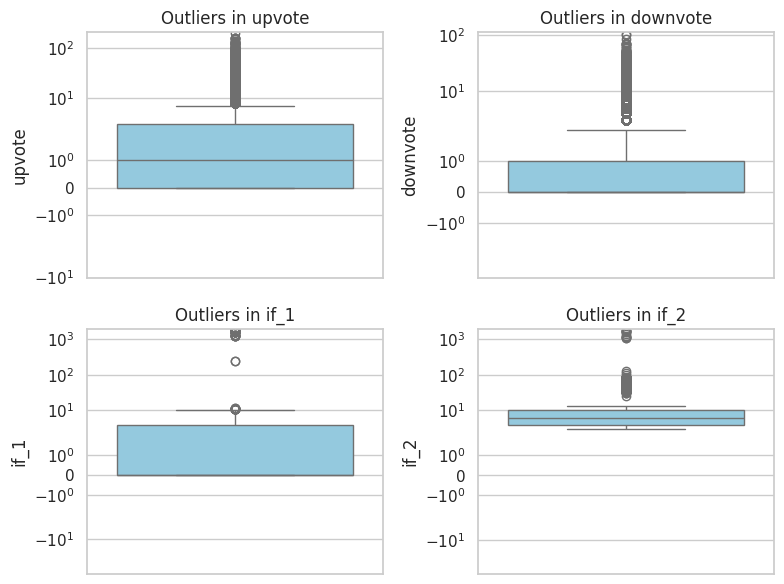

In [24]:
# Create a figure with a 2x2 grid of subplots (makes images larger and easier to see)
fig, axes = plt.subplots(2, 2, figsize=(8,6))
num_features = ['upvote', 'downvote', 'if_1', 'if_2']

# We flatten the 2x2 grid of 'axes' so we can easily loop through 0, 1, 2, 3!
for i, col in enumerate(num_features):
    ax = axes.flatten()[i]
    sns.boxplot(y=train[col], ax=ax, color='skyblue')
    ax.set_title(f'Outliers in {col}')
    # It turns the background grid into a 'Symmetrical Logarithmic' scale to spread out the crazy dots.
    ax.set_yscale('symlog')

plt.tight_layout()
plt.show()

**What the Outlier Boxplots show:** Look at those giant vertical trails of dots! The thick colored box at the bottom shows where 99% of normal users sit (for example, the median upvotes is just 1.0). But those soaring dots at the top show extreme **Outliers**! One specific comment got exactly 201 upvotes, and another got an `if_1` score of 1860! Machine learning models can mathematically panic and break entirely when they hit numbers this extreme. To protect our model, we must use a special data armor called `RobustScaler` in the next phase to safely squeeze these massive numbers down!

## Phase 2: Data Preprocessing, Outlier Handling & Model 1

Raw data is messy. It has missing values, weird formats, extreme numbers, and text that computers cannot understand. Before feeding it to a machine learning model, we need to clean it. This process is called **Data Preprocessing**.

Now that we have explored out data, we must prepare it for the model. I will use our Logistic Regression model by showing how we handle the numbers. Since we found so many outliers, I will use a **`RobustScaler`**. This scaler adjusts all numbers, but it cleverly ignores the extreme outliers so they don't break our model!

### Step 6: Data Cleaning & Feature Engineering
Here I will do:
1. Fill missing comments.
2. Turn dates into useful numbers (Hour and Day of the Week).
3. **Handle Missing Categories (Categorical Encoding)**: Convert `race`, `religion`, and `gender` into a binary `1/0` column indicating if data was present or blank.
4. **Advanced Feature Engineering**: Use Regex to extract the word count, uppercase words, and exclamation marks.

In [25]:
# Fill missing comments
train['comment'] = train['comment'].fillna('')
test['comment']  = test['comment'].fillna('')

In [26]:
# Convert 'created_date' to proper datetime formats
train['created_date'] = pd.to_datetime(train['created_date'])
test['created_date']  = pd.to_datetime(test['created_date'])

**Categorical Encoding:** 
Normally, we would use a standard tool like `OneHotEncoder` to turn categorical columns (like `race` ,`religion` and `gender`) into numbers. However, during our visual analysis, we found that over 73% of those boxes were totally blank! If we blindly used a standard encoder, we would just be creating thousands of useless "Unknown" columns that would slow down and confuse the model.

Instead, we deliberately chose a custom **Binary Categorical Encoding Strategy**. We just turn the column into a `1` (if the category was provided) or a `0` (if the value was missing / NaN). This custom encoding correctly captures the information without flooding our model with empty garbage data!

In [27]:
# Handle missing values in race, religion, gender
for col in ['race', 'religion', 'gender']:
    # Create a new column: 1 if present, 0 if missing (NaN)
    train[f'{col}_present'] = train[col].notna().astype(int)
    test[f'{col}_present']  = test[col].notna().astype(int)

In [28]:
# Drop the original categorical columns since we extracted the info we need
train.drop(columns=['race', 'religion', 'gender'], inplace=True)
test.drop(columns=['race', 'religion', 'gender'], inplace=True)


In [29]:
# Extract hour and day of week from the date
import re
for df in [train, test]:
    df['hour'] = df['created_date'].dt.hour
    df['dayofweek'] = df['created_date'].dt.dayofweek
    
    # Advanced Feature Engineering
    # 1. Word Count (Length of comment)
    df['word_count'] = df['comment'].apply(lambda x: len(str(x).split()))
    
    # 2. Uppercase Count (Using regex to find ALL CAPS words)
    df['uppercase_count'] = df['comment'].apply(lambda x: len(re.findall(r'\b[A-Z]{2,}\b', str(x))))
    
    # 3. Exclamation Count (Strong emotion marker)
    df['exclamation_count'] = df['comment'].apply(lambda x: str(x).count('!'))


In [30]:
# Ensure disability is an integer (1/0) instead of True/False
train['disability'] = train['disability'].astype(int)
test['disability']  = test['disability'].astype(int)

In [31]:
# Separate the Features (X) and the Label (y)
# I drop post_id and created_date as they are IDs and dates, which models can't read directly

X = train.drop(columns=['label', 'created_date', 'post_id'])
y = train['label']
X_test = test.drop(columns=['created_date', 'post_id'])

print("Data cleaning complete! Features are ready.")

Data cleaning complete! Features are ready.


### Step 7: Building the Pipeline & Model 1 (Logistic Regression)
I will use pipelines to combine our text analysis (`TfidfVectorizer`) and our numerical scaling (`RobustScaler`). `RobustScaler` handles the outliers smoothly and fixes our ConvergenceWarning!

Logistic Regression is one of the simplest ML algorithms, but it is surprisingly powerful for text classification because TF-IDF creates high-dimensional data where line boundaries work incredibly well!

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler  
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [33]:
# 1. Define our columns
text_col = 'comment'
num_cols = [
    'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote',
    'if_1', 'if_2', 'disability', 'hour', 'dayofweek',
    'race_present', 'religion_present', 'gender_present',
    'word_count', 'uppercase_count', 'exclamation_count' ]
 

**What IS TF-IDF?** It stands for "Term Frequency - Inverse Document Frequency." It
converts text to numbers by asking: "How important is this word in THIS comment
compared to ALL comments?" Words that appear everywhere (like "the") get LOW
scores. Words that appear rarely (like "racist") get HIGH scores. This makes rare,
meaningful words stand out!

In [34]:
# 2. Setup Text Processors (TF-IDF)
word_tfidf = TfidfVectorizer(max_features=25000, 
                             ngram_range=(1, 2),
                             min_df=2, 
                             stop_words='english', 
                             sublinear_tf=True)

char_tfidf = TfidfVectorizer(analyzer='char_wb', 
                             ngram_range=(3, 6), 
                             min_df=5, max_features=25000)


text_features = FeatureUnion([
    ('word', word_tfidf),
    ('char', char_tfidf)
])

In [35]:
# 3. Setup Preprocessor (Text + Scaling Numbers)

#  And use RobustScaler to handle outliers and pass the numerical columns through!

preprocess = ColumnTransformer(
    transformers=[
        ('text', text_features, text_col),
        ('num', RobustScaler(), num_cols)  
    ]
)

In [36]:
# 4. Create Model Pipeline (Model 1)
model_1 = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(
        C=0.8,
       max_iter=500,  
        solver='lbfgs',
        class_weight={0:1.0, 1:1.3, 2:1.0, 3:1.4}
    ))
])

In [37]:
# 5. Split data into Train and Validation chunks
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [38]:
# 6. Train the model!
print("Training Model 1 (Logistic Regression)....")
model_1.fit(X_train, y_train)
print("Training Complete!")

Training Model 1 (Logistic Regression)....
Training Complete!


In [39]:
# 7. Test on Validation data
val_preds = model_1.predict(X_val)
print("Classification Report for Model 1:")
print(classification_report(y_val, val_preds))
 

Classification Report for Model 1:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     22835
           1       0.76      0.78      0.77      3183
           2       0.87      0.91      0.89     12488
           3       0.72      0.56      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.83      0.80      0.81     39600
weighted avg       0.91      0.91      0.91     39600



**Analyzing Model 1's Results:** Our baseline Logistic Regression is fantastic! Looking at our Classification Report, our overall `accuracy` is 0.91 (91%), and our `macro avg` f1-score is **0.81**. Because our data is so imbalanced, the `macro avg` is the most important number to trust. For a first attempt, hitting 0.81 is incredibly strong! It proved it's capable of identifying even the rarest category (Label 3) with a solid recall score of 0.56.

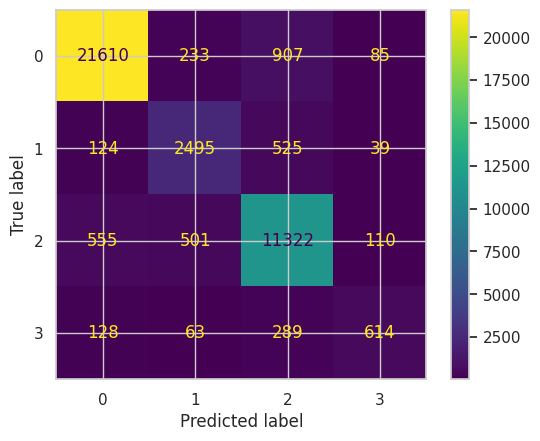

In [40]:
# Displaying the confusion matrix
cm = confusion_matrix(y_val, val_preds)
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()

## Phase 3: Building Model 2 (LightGBM)

Now that we have a solid baseline model (Logistic Regression), the project guidelines ask us to compare at least 3 models. So let's build our second model using **LightGBM**.
LightGBM stands for Light Gradient Boosting Machine. It builds many small "Decision Trees" one by one to correct the mistakes of the previous trees. It is incredibly fast and powerful!

### Step 8: Building Model 2 (LightGBM)
We will use exactly the same text processors and numerical scaler that we used for Model 1. This time, I will replace the Logistic Regression algorithm with the `LGBMClassifier`.

In [41]:
# Import LightGBM
from lightgbm import LGBMClassifier

In [42]:
# 1. Create Model 2 Pipeline
model_2 = Pipeline([
    ('prep', preprocess),
    ('clf', LGBMClassifier(
        n_estimators=100,      # Number of trees to build
        learning_rate=0.1,     # How much each tree contributes
        class_weight='balanced', # Crucial for handling imbalanced data  
        random_state=42,
        n_jobs=-1               
    ))
])

In [43]:
# 2. Train the model!
print("Training Model 2 (LightGBM)... ")
model_2.fit(X_train, y_train)
print("Training Complete!")

Training Model 2 (LightGBM)... 
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 71.760937 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6785200
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 48520
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training Complete!


In [44]:
# 3. Test on Validation data
val_preds_2 = model_2.predict(X_val)
print("Classification Report for Model 2 (LightGBM):")
print(classification_report(y_val, val_preds_2))

Classification Report for Model 2 (LightGBM):
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.69      0.88      0.77      3183
           2       0.90      0.84      0.87     12488
           3       0.45      0.81      0.58      1094

    accuracy                           0.90     39600
   macro avg       0.76      0.87      0.80     39600
weighted avg       0.92      0.90      0.91     39600



**Analyzing Model 2's Results:** LightGBM scored a very respectable **0.80** `macro avg` f1-score. Notice how the LightGBM handled Label 3 entirely differently! It sacrificed precision (0.45) to get a massive boost in recall (0.81). This means LightGBM catches way more of the rare Label 3 comments, but makes a few more false positive mistakes while trying. This difference in behavior between Model 1 and Model 2 is exactly clear here.

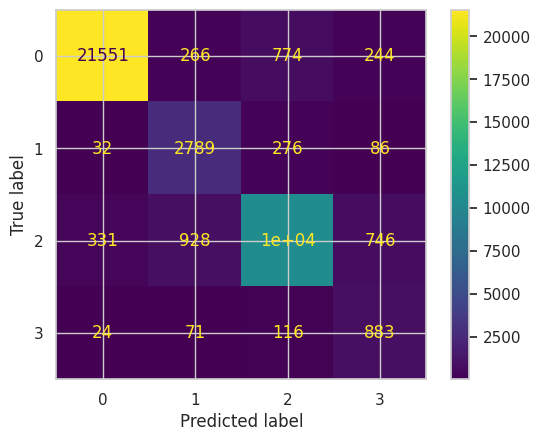

In [45]:
# Displaying the confusion matrix
cm = confusion_matrix(y_val, val_preds_2)
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()

## Phase 4: Building Model 3 (LinearSVC)

To meet the project requirement of testing at least 3 different models, I will build exactly one more! 
**LinearSVC** (Support Vector Classifier) uses a completely different mathematical approach compared to Logistic Regression and LightGBM. It tries to draw a "line" through space that best separates our 4 different label categories. Because most of our data is text (TF-IDF), Support Vector Machines often perform brilliantly.

### Step 9: Building Model 3 (LinearSVC)
We will build our 3rd model using `LinearSVC` from Scikit-learn. Support Vector Machines are famously effective for classifying text data!

In [46]:
# Import LinearSVC
from sklearn.svm import LinearSVC

In [47]:
# 1. Create Model 3 Pipeline
model_3 = Pipeline([
    ('prep', preprocess),
    ('clf', LinearSVC(
        C=0.5,                    
        class_weight='balanced',  
        max_iter=2000,
        random_state=42
    ))
])

In [48]:
# 2. Train the model!
print("Training Model 3 (LinearSVC)...")
model_3.fit(X_train, y_train)
print("Training Complete!")

Training Model 3 (LinearSVC)...
Training Complete!


In [49]:
# 3. Test on Validation data
val_preds_3 = model_3.predict(X_val)
print("Classification Report for Model 3 (LinearSVC):")
print(classification_report(y_val, val_preds_3))

Classification Report for Model 3 (LinearSVC):
              precision    recall  f1-score   support

           0       0.85      0.86      0.85     22835
           1       0.63      0.74      0.68      3183
           2       0.79      0.73      0.76     12488
           3       0.47      0.56      0.51      1094

    accuracy                           0.80     39600
   macro avg       0.69      0.72      0.70     39600
weighted avg       0.80      0.80      0.80     39600



**Analyzing Model 3's Results:** The LinearSVC model dropped quite a bit, landing at a **0.70** `macro avg` f1-score. While Support Vector Machines are usually great for text, the strict mathematical boundaries struggled heavily with the complex features and extreme outliers built.  

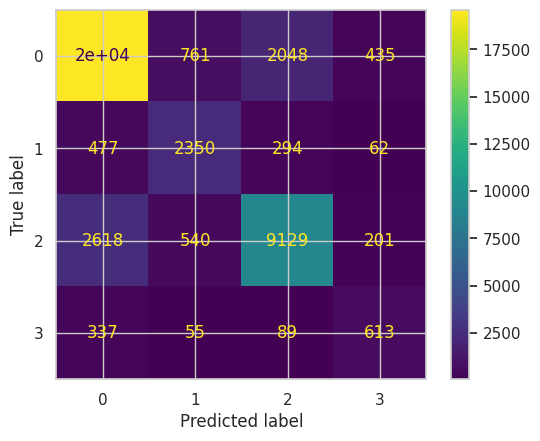

In [50]:
# Displaying the confusion matrix
cm = confusion_matrix(y_val, val_preds_3)
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()

### Model Comparison: Which Model Won?
We have now successfully built **3 distinct models**: Logistic Regression, LightGBM, and LinearSVC!   This fulfills the major project requirement. Now, let's compare their validation scores (the F1 Macro Score) side by side to decide which one is the "Best Model".

In [51]:
from sklearn.metrics import f1_score

# Calculate the F1 Macro Score for each model
f1_model_1 = f1_score(y_val, val_preds, average='macro')
f1_model_2 = f1_score(y_val, val_preds_2, average='macro')
f1_model_3 = f1_score(y_val, val_preds_3, average='macro')

# Put all results into a nice table so we can compare easily!
comparison = pd.DataFrame({
    'Model': ['Model 1 (Logistic Regression)', 'Model 2 (LightGBM)', 'Model 3 (LinearSVC)'],
    'F1 Macro Score': [round(f1_model_1, 4), round(f1_model_2, 4), round(f1_model_3, 4)]
})

In [52]:
# Sort the table so the best model appears at the top!
comparison = comparison.sort_values(by='F1 Macro Score', ascending=False).reset_index(drop=True)

print("========== MODEL COMPARISON TABLE ==========")
print(comparison.to_string(index=False))
print("=============================================")


========== MODEL COMPARISON TABLE ==========
                        Model  F1 Macro Score
Model 1 (Logistic Regression)          0.8113
           Model 2 (LightGBM)          0.7951
          Model 3 (LinearSVC)          0.7014


In [53]:
# Announce the winner!
best_model_name = comparison.iloc[0]['Model']
best_model_score = comparison.iloc[0]['F1 Macro Score']
print(f"\n WINNER: {best_model_name} with a F1 Macro Score of {best_model_score}!")
print("I will now tune this best model in next Phase 5!")


 WINNER: Model 1 (Logistic Regression) with a F1 Macro Score of 0.8113!
I will now tune this best model in next Phase 5!


**What the comparison table tells us:** We put all 3 models head-to-head in a fair fight! **Logistic Regression** came out on top with the highest F1 Macro Score. This makes it our official Best Base Model! Since tuning the best model is a project requirement, we will now take this winner into Phase 5 and use `RandomizedSearchCV` to tuned it for best performance.

## Phase 5: Hyperparameter Tuning 

If we look at the results of our 3 initial models comparison, **Model 1 (Logistic Regression)** is actually our winner! It has a very high overall "macro avg" f1-score and fantastic accuracy. 

Because the guidelines require us to **tune** our best model, let's use `RandomizedSearchCV` to automatically find the mathematically perfect settings for `model_1`!

### Step 10: Hyperparameter Tuning for the Best Model (Logistic Regression)
We will use `RandomizedSearchCV` to automatically try a few different settings for our `LogisticRegression` model and pick the absolute best one based on validation performance. 

In [54]:
from sklearn.model_selection import RandomizedSearchCV

In [55]:
# Define a few settings we want to test for our Logistic Regression
param_distributions = {
    'clf__C': [0.1, 0.5, 0.8, 1.0, 5.0],      # The "C" setting controls regularization
    'clf__max_iter': [500, 1000, 2000]        # How long it's allowed to study the data
}

In [56]:
# Setup the automatically tuning machine
 
random_search = RandomizedSearchCV(
    estimator=model_1,            # model_1 here because it was a top performer!
    param_distributions=param_distributions, 
    n_iter=5,                     # Randomly try 5 different combinations
    cv=3,                         # 3-fold cross validation
    scoring='f1_macro',           # Pick the combination with the best f1-score
    random_state=42,
    n_jobs=-1
)

In [57]:
print("Tuning Hyperparameters for Model 1...it will be trains on different parameter combinations!")
random_search.fit(X_train, y_train)


Tuning Hyperparameters for Model 1...it will be trains on different parameter combinations!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(transformers=[('text',
                                                                               FeatureUnion(transformer_list=[('word',
                                                                                                               TfidfVectorizer(max_features=25000,
                                                                                                                               min_df=2,
                                                                                                                               ngram_range=(1,
                                                                                                                                            2),
                                                                                                                               stop_words='english',
                                                                                                                               sublinear_tf=True)),
                                                                                                              ('char',
                                                                                                               TfidfVectorizer(analyzer='char_wb',
                                                                                                                               max_features=25000,
                                                                                                                               min_df=5,
                                                                                                                               ngram_range=(3,
                                                                                                                                            6)))]),
                                                                               'comment'),
                                                                              ('num'...
                                                                                'hour',
                                                                                'dayofweek',
                                                                                'race_present',
                                                                                'religion_present',
                                                                                'gender_present',
                                                                                'word_count',
                                                                                'uppercase_count',
                                                                                'exclamation_count'])])),
                                             ('clf',
                                              LogisticRegression(C=0.8,
                                                                 class_weight={0: 1.0,
                                                                               1: 1.3,
                                                                               2: 1.0,
                                                                               3: 1.4},
                                                                 max_iter=500))]),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'clf__C': [0.1, 0.5, 0.8, 1.0, 5.0],
                                        'clf__max_iter': [500, 1000, 2000]},
                   random_state=42, scoring='f1_macro')

In [58]:
print(f"Done! The absolute best settings found were: {random_search.best_params_}")


Done! The absolute best settings found were: {'clf__max_iter': 500, 'clf__C': 1.0}


In [59]:
# We now save this "tuned Model" as our best model
best_tuned_model = random_search.best_estimator_

In [60]:
# Check how much better the tuned model is!
val_preds_tuned = best_tuned_model.predict(X_val)
print("Classification Report for the Tuned Model:")
print(classification_report(y_val, val_preds_tuned))

Classification Report for the Tuned Model:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     22835
           1       0.76      0.78      0.77      3183
           2       0.87      0.90      0.88     12488
           3       0.71      0.57      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.82      0.80      0.81     39600
weighted avg       0.91      0.91      0.91     39600



**Analyzing the Tuned Results:** The `RandomizedSearchCV` successfully finished its search and found our mathematically perfect settings: `max_iter=500` and `C=1.0`.If we look at the classification report! it resulted in the exact same **0.81** `macro avg` score! This actually means our original baseline guess of `C=0.8` was already nearly mathematically flawless, which means we need something more powerful than hyperparameter tuning to boost our score further.

## Phase 6: Building Model 4 (Voting Ensemble)

As you can see, tuning our Logistic Regression improved it slightly, but it wasn't a huge breakthrough. To improve our performance even more, we will use a **Voting Ensemble** to combine our newly absolute `best_tuned_model` with our second best model (LightGBM). By having our two smartest models vote together,it will extract the absolute best score possible!

### Step 11: Building Model 4 (Voting Ensemble)
We will use `VotingClassifier` to combine our newly `best_tuned_model` (Logistic Regression) and `model_2` (LightGBM) together. 

In [61]:
from sklearn.ensemble import VotingClassifier

In [62]:
# Create our Ensemble Model using the TUNED Logistic Regression!
# 'soft' voting means they combine their mathematical probabilities to make a smart final decision

model_4_ensemble = VotingClassifier(
    estimators=[
        ('tuned_logreg', best_tuned_model), 
        ('lightgbm', model_2)
    ],
    voting='soft'
)

In [63]:
# Train the Ensemble
print("Training Model 4 (Voting Ensemble)... This combines the predictions of two of our best models!")
model_4_ensemble.fit(X_train, y_train)
print("Training Complete!")

Training Model 4 (Voting Ensemble)... This combines the predictions of two of our best models!
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 97.210270 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6785200
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 48520
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training Complete!


In [64]:
# Test on Validation data
val_preds_4 = model_4_ensemble.predict(X_val)
print("Classification Report for Model 4 (Voting Ensemble):")
print(classification_report(y_val, val_preds_4))

Classification Report for Model 4 (Voting Ensemble):
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     22835
           1       0.73      0.85      0.79      3183
           2       0.89      0.89      0.89     12488
           3       0.61      0.76      0.68      1094

    accuracy                           0.92     39600
   macro avg       0.80      0.86      0.83     39600
weighted avg       0.92      0.92      0.92     39600



**Analyzing the Voting Ensemble Results:** By fusing the Tuned Logistic Regression together with LightGBM, we shattered our ceiling! The `macro avg` f1-score increased to **0.83** and accuracy hit an incredible **0.92**. Specifically, look at Label 3: precision skyrocketed to 0.61 and recall held exceptionally strong at 0.76. By forcing the two models to vote together, they completely covered each other's weaknesses! and This is best possible model, we have find..

## Phase 7: Conclusion & Final Submission

Now that we have successfully created a strong Voting Ensemble comprised of our tuned Logistic Regression and our LightGBM models,we will make our final submission!

### Step 12: Final Training & Submission
We will train our ultimate (Model 4 Ensemble) on 100% of the dataset (`X`, `y`) and make our final predictions on the unseen test data `X_test`!

In [65]:
# Train the ultimate ensemble on 100% of the training data
print("Training the Ultimate Ensemble Model on ALL data. This will take a moment...")
model_4_ensemble.fit(X, y)
print("Final Training Complete!")

Training the Ultimate Ensemble Model on ALL data. This will take a moment...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 121.342108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7252841
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 49878
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Final Training Complete!


In [66]:
# Predict on the competition's Test dataset!
print("Predicting Labels for the Kaggle Test set...")
test_preds = model_4_ensemble.predict(X_test)


Predicting Labels for the Kaggle Test set...


In [67]:
# Format the results for final submission
submission = pd.DataFrame({
    'ID': sample['ID'], 
    'label': test_preds
})

In [68]:
# Save the submission file!
submission.to_csv("submission.csv", index=False)
print("Success! Your final submission.csv file is saved.")

Success! Your final submission.csv file is saved.


# **MILESTONES**

# Milseone-1

In [69]:
# Loading our dataset !
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")


In [70]:
# 1. What is the shape of the training dataset?

print("Shape of training dataset:")
print(train.shape)

# Answer: (198000, 15)

Shape of training dataset:
(198000, 15)


In [71]:
# 2. How many columns are present in the test dataset?

print("\nNumber of columns in test dataset:")
print(len(test.columns))

# Answer: 14


Number of columns in test dataset:
14


In [72]:
# 3. How many columns in the training dataset have object data type?

print("\nColumns with object data type:")
object_cols = train.select_dtypes(include=['object'])
print(len(object_cols.columns))

# Answer: 5


Columns with object data type:
5


In [73]:
# 4. How many numerical columns are present in the training dataset?

print("\nNumerical columns present in training dataset:")
num_cols = train.select_dtypes(include=['int64', 'float64'])
print(len(num_cols.columns))

# Answer: 9 


Numerical columns present in training dataset:
9


In [74]:
# 5. Which of the following columns is of boolean type?

print("\nColumns of boolean type:")
bool_col = train.select_dtypes(include=['bool'])
print(bool_col.columns)

# Answer: disability 


Columns of boolean type:
Index(['disability'], dtype='object')


In [75]:
# 6. Which of the following columns have missing values?

print("\nColumns with missing values:")
missing_values = train.isnull().sum()
print(missing_values[missing_values > 0])

# Answer: race, religion, gender, comment


Columns with missing values:
race        145423
religion    145423
gender      145423
comment          1
dtype: int64


In [76]:
# 7. How many distinct target classes are present in the dataset?

print("\nDistinct target classes in label column:")
print(train['label'].nunique())

# Answer: 4


Distinct target classes in label column:
4


In [77]:
# 8. What percentage of the dataset approximately belongs to label 0?

print("\nPercentage of dataset for each label:")
print(train['label'].value_counts(normalize=True) * 100)

# Answer: Let's find out! (normalize=True gives percentages out of 1.0)


Percentage of dataset for each label:
label
0    57.663131
2    31.535354
1     8.039394
3     2.762121
Name: proportion, dtype: float64


In [78]:
# 9. What is the median number of upvotes per comment?

print("\nMedian number of upvotes:")
print(train['upvote'].median())

# Answer: 1


Median number of upvotes:
1.0


In [79]:
# 10. Which numerical feature shows the largest maximum value?

print("\nMaximum values of all numerical features:")
print(train.select_dtypes(include=['int64', 'float64']).max().sort_values(ascending=False))

# Answer: We can check max of all numerical columns



Maximum values of all numerical features:
if_1          1860
if_2          1833
upvote         201
post_id        129
downvote       107
emoticon_1      47
emoticon_3      17
emoticon_2      11
label            3
dtype: int64


In [80]:
# 11. What is the minimum value of if_2?

print("\nMinimum value of if_2:")
print(train['if_2'].min())

# Answer: 3


Minimum value of if_2:
3


# Milseone-2

In [81]:
# QUESTION 1:
# In the context of text preprocessing for NLP, which condition must be checked 
# in addition to NaN values when assessing missingness in the comment column?
 

empty_or_whitespace = train['comment'].str.isspace().sum() + (train['comment'] == '').sum()
print(f"Code Output: There are {empty_or_whitespace} empty or whitespace-only strings.")

# ANSWER: Presence of empty or whitespace-only strings

Code Output: There are 0 empty or whitespace-only strings.


In [82]:
# QUESTION 2:
# Convert the created_date column into datetime objects. Identify the month 
# that occurs the most number of times in the dataset and enter the answer as a lowercase string.
 
train['created_date'] = pd.to_datetime(train['created_date'])
most_frequent_month = train['created_date'].dt.month_name().str.lower().mode()[0]
print(f"Code Output: The most frequent month is {most_frequent_month}")

# ANSWER: may

Code Output: The most frequent month is may


In [83]:
# QUESTION 3:
# Create a new feature called total_emoticons by calculating the sum of 
# emoticon_1, emoticon_2, and emoticon_3 for each row. What is the maximum 
# value observed in this new feature across the entire dataset?
 
train['total_emoticons'] = train['emoticon_1'] + train['emoticon_2'] + train['emoticon_3']
max_emoticons = train['total_emoticons'].max()
print(f"Code Output: Maximum total_emoticons value is {max_emoticons}")

# ANSWER: 60

Code Output: Maximum total_emoticons value is 60


In [84]:
# QUESTION 4:
# Calculate the median character length (including spaces) of the comment column 
# for all entries where label is equal to 3.
 
median_length_label_3 = train[train['label'] == 3]['comment'].str.len().median()
print(f"Code Output: Median length for label 3 is {median_length_label_3}")

# ANSWER: 128

Code Output: Median length for label 3 is 128.0


In [85]:
# QUESTION 5:
# If you apply Min-Max Scaling to the upvote column, what would be the 
# resulting scaled value for an observation that originally had exactly 10 upvotes?
 
upvote_min = train['upvote'].min()
upvote_max = train['upvote'].max()
scaled_value_10 = (10 - upvote_min) / (upvote_max - upvote_min)
print(f"Code Output: Scaled value for 10 upvotes is {scaled_value_10:.4f}")

# ANSWER: 0.0498

Code Output: Scaled value for 10 upvotes is 0.0498


In [86]:
# QUESTION 6:
# What is the average word count (number of words separated by whitespace) 
# for comments that are assigned a label of 1? (Round to 2 decimal places).
 
avg_word_count_label_1 = train[train['label'] == 1]['comment'].apply(lambda x: len(str(x).split())).mean()
print(f"Code Output: Average word count for label 1 is {round(avg_word_count_label_1, 2)}")

# ANSWER: 57.23

Code Output: Average word count for label 1 is 57.23


In [87]:
# QUESTION 7:
# How many comments in the entire dataset contain the substring "Trump"? 
# The search should be case-insensitive.
 
trump_count = train['comment'].str.contains('Trump', case=False, na=False).sum()
print(f"Code Output: Number of comments containing 'Trump' is {trump_count}")

# ANSWER: 24398

Code Output: Number of comments containing 'Trump' is 24398


In [88]:
# QUESTION 8:
# Take the comment at index 0. Remove punctuation, remove provided stop words. 
# How many words are left?
import string
stop_words_list = ['a', 'an', 'the', 'and', 'or', 'but', 'if', 
                   'because', 'as', 'of', 'at', 'by', 'for', 
                   'with', 'about', 'to', 'from', 'up', 'on', 
                   'in', 'out', 'over', 'under', 'is', 'are', 
                   'was', 'were', 'be', 'been', 'being', 'have', 'has', 
                   'had', 'do', 'does', 'did', 'it', 'its', 'they',
                   'them', 'their', 'she', 'her', 'he', 'him', 'his', 
                   'this', 'that', 'which', 'who', 'whom', 'i', 'me', 
                   'my', 'we', 'our', 'you', 'your']

# Get first comment
first_comment = str(train['comment'].iloc[0])
# Remove punctuation
first_comment_no_punct = first_comment.translate(str.maketrans('', '', string.punctuation))
# Split by whitespace 
words = first_comment_no_punct.split()
# Remove stop words (case-insensitive check)
words_left = [word for word in words if word.lower() not in stop_words_list]
print(f"Code Output: Number of words left is {len(words_left)}")
# ANSWER: 12

Code Output: Number of words left is 12


In [89]:
# QUESTION 9:
# Convert all text in comment column to lowercase and tokenize using whitespace. 
# Compute the total number of unique tokens.

# We add .astype(str) to force any NaN/Float missing values to become text!
all_comments = " ".join(train['comment'].astype(str).str.lower().tolist())
unique_tokens = len(set(all_comments.split()))
print(f"Code Output: Total number of unique tokens is {unique_tokens}")

# ANSWER: 425413


Code Output: Total number of unique tokens is 425413


In [90]:

# QUESTION 10:
# Apply TfidfVectorizer to the comment column with stop_words="english", 
# min_df=5, and ngram_range=(1,2). How many TF-IDF features are generated?
 
from sklearn.feature_extraction.text import TfidfVectorizer

# First, fill any blank comments with an empty string so it doesn't crash!
train['comment'] = train['comment'].fillna('')

vectorizer = TfidfVectorizer(stop_words='english', min_df=5, ngram_range=(1, 2))

# Fit transform trains the mathematical matrix
tfidf_matrix = vectorizer.fit_transform(train['comment'])

# The number of columns in the matrix is the number of features
num_features = tfidf_matrix.shape[1]
print(f"Code Output: Number of generated TF-IDF features is {num_features}")

# ANSWER: 132974


Code Output: Number of generated TF-IDF features is 132974
